https://www.science.org/doi/abs/10.1126/scitranslmed.adw4148

They are showing that there are immuno-dominant antibodies for peanuts that are germline encoded: for some of the antibodies they extracted from serum that bind the epitope, they made the reversion to germline and saw that they still bind, although not as well as the evolved antibody. I wanted to see whether the affinity maturation mutations they are seeing are also "germline encoded" in the sense that they are highly likely to occur in SHM; this would mean that they are more likely to exist even if the individual did not enounter this epitop yet. I took one example from the paper (antibody 23D12), took the germline sequence for that V and J combination and calculated the SHM mutation rates with thrifty (rate * mutation probability, assuming a reference branch length of 1 as in surprising_sites.ipynb).
I then plotted all of the "absolute" substitution rates for the germline sequence, while highlighting the substitutions for which they observed codons with even higher affinity to the epitope **[cell 16]**. Notice that for the yellow transitions, there are two ways to get to codon K from the germline, and so the two rates need to be summed. They are all in the top 20% of possible mutations, but this could just be a function of them being in the CDRs..

Not sure this specific example is interesting, but general idea:
How much of the affinity maturation is "germline encoded" in immunodominant settings, in the sense that the most common mutations in SHM are also the most successful? How does this compare to "private antibodies"/non-immuno-dominant ones

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from Bio.Seq import Seq
import torch

from torch.nn import functional as F

from netam import pretrained
from netam.models import DEFAULT_NEUTRAL_MODEL

from dnsmex.dxsm_data import pcp_df_of_nickname
from dnsmex.local import localify

figures_dir = localify("FIGURES_DIR")
neutral_model_name = DEFAULT_NEUTRAL_MODEL

### Mutability analysis

In [2]:
def mutability_df_of_mean_mutability(mean_mutability):
    mutability_df = mean_mutability.to_frame()
    mutability_df.columns = ["mutability"]
    mutability_df["nt_site"] = range(1, len(mean_mutability) + 1)
    mutability_df["aa_site"] = (mutability_df["nt_site"] + 2) // 3
    mutability_df = mutability_df[mutability_df["nt_site"] < 350]
    return mutability_df


def plot_mutability_with_highlights(df, aa_sites):
    fig, ax = plt.subplots(figsize=(10, 4))  
    
    ax.plot(df['nt_site'], df['mutability'], label='Mutability', color='gray', alpha=0.7)
    
    prop_cycle = plt.rcParams['axes.prop_cycle']
    colors = prop_cycle.by_key()['color']
    
    for i, aa_site in enumerate(aa_sites):
        # Extract rows corresponding to the specific amino acid site.
        highlighted = df[df['aa_site'] == aa_site]
        
        ax.scatter(highlighted['nt_site'], highlighted['mutability'], color=colors[i % len(colors)], label=f'AA Site {aa_site}')
    
    ax.set_title('Neutral mutability prediction')
    ax.set_xlabel('Nucleotide Site')
    ax.set_ylabel('Mutability')
    ax.legend()
    
    ax.grid(True, which='both', linestyle='--', linewidth=0.5)
    plt.tight_layout()
    
    return fig


def single_mut_df_of_csp_logits(csp_logits, aa_site, original_codon):
    per_codon_csps = F.softmax(csp_logits, dim=2).mean(axis=0)[(aa_site-1)*3:aa_site*3]
    per_codon_csps_df = pd.DataFrame(per_codon_csps.detach().numpy(), columns=["A", "C", "G", "T"])

    # Calculate single-mut transition probabilities.
    single_mut_transitions = []
    for i, nt in enumerate(original_codon):
        for mut_nt in "ACGT":
            if mut_nt != nt:
                # Create the mutated codon.
                mutated_codon = original_codon[:i] + mut_nt + original_codon[i+1:]
                # Get the mutation probability.
                prob = per_codon_csps_df.loc[i, mut_nt]
                single_mut_transitions.append((original_codon, mutated_codon, prob, i))

    # Convert single-mut transitions into a DataFrame.
    single_mut_df = pd.DataFrame(single_mut_transitions, columns=['From', 'To', 'Probability', "Mutated_Position"])
    return single_mut_df


def codon_to_aa(codon):
    return str(Seq(codon).translate())


def collect_codon_transitions(our_df, site):
    # Function to translate codon to AA.
    def codon_to_aa(codon):
        try:
            return str(Seq(codon).translate())
        except:
            return None  # Handle invalid codons.
    
    # Calculate codon transitions.
    transitions = our_df.apply(lambda row: (row["parent_heavy"][3*(site-1):3*site], row["child_heavy"][3*(site-1):3*site]), axis=1)
    # Note that in the following code snippet we only use codon_to_aa to test if the codon codes for an AA.
    valid_transitions = transitions[transitions.apply(lambda x: x[0] != x[1] and None not in [codon_to_aa(x[0]), codon_to_aa(x[1])])]
    transition_counts = valid_transitions.value_counts()

    # Translate codons to AAs and format the index.
    transition_counts.index = transition_counts.index.map(lambda t: f"{t[0]} ({codon_to_aa(t[0])}) -> {t[1]} ({codon_to_aa(t[1])})")
    rows_with_transitions = our_df.loc[valid_transitions.index].copy()
    rows_with_transitions["nonsynonymous"] = rows_with_transitions.apply(lambda row: codon_to_aa(row["parent_heavy"][3*(site-1):3*site]) != codon_to_aa(row["child_heavy"][3*(site-1):3*site]), axis=1)
    return rows_with_transitions, transition_counts


class MutabilityContainer:
    def __init__(self, pcp_df, neutral_model_name):
        crepe = pretrained.load(neutral_model_name)
        self.pcp_df = pcp_df
        if len(pcp_df) > 1000:
            self.subset_df = pcp_df.sample(1000)
        else:
            self.subset_df = pcp_df.copy()
        self.rates, self.csp_logits = crepe(self.subset_df["parent_heavy"])
        mean_mutability = pd.Series(self.rates.mean(axis=0))
        self.mutability_df = mutability_df_of_mean_mutability(mean_mutability)
    
    def find_majority_codon(self, aa_site):
        codons = [seq[3*(aa_site-1):3*aa_site] for seq in self.subset_df["parent_heavy"]]
        value_counts = pd.Series(codons).value_counts()
        print("top 5 codons (check to make sure we have a clear majority):")
        print(value_counts[:5])
        return value_counts.index[0]
    
    def plot_mutability_with_highlights(self, aa_sites):
        return plot_mutability_with_highlights(self.mutability_df, aa_sites)

    def codon_transition_probs(self, aa_site, original_codon=None):
        if original_codon is None:
            original_codon = self.find_majority_codon(aa_site)
        single_mut_df = single_mut_df_of_csp_logits(self.csp_logits, aa_site, original_codon)
        mean_rates = self.mutability_df["mutability"].values
        weighted_prob_single = single_mut_df.apply(
            lambda row: row.Probability * mean_rates[3*aa_site + row.Mutated_Position], axis=1)
        single_mut_df['Probability'] = weighted_prob_single / weighted_prob_single.sum()
        return single_mut_df

    def single_codon_transition_df(self, aa_site):
        """
        Build a DataFrame with the single mutation transition probabilities and empirical counts
        for a given amino acid site.
        """
        _, codon_transitions = collect_codon_transitions(self.pcp_df, aa_site)
        
        # Filter to only single nucleotide changes.
        def is_single_nucleotide_change(transition_str):
            # Extract codons from transition string like "ACA (T) -> ATA (I)".
            codons = transition_str.split(' -> ')
            from_codon = codons[0].split(' (')[0]
            to_codon = codons[1].split(' (')[0]
            
            # Count differences.
            differences = sum(c1 != c2 for c1, c2 in zip(from_codon, to_codon))
            return differences == 1
        
        # Filter transitions to single nucleotide changes only.
        single_nt_transitions = codon_transitions[codon_transitions.index.map(is_single_nucleotide_change)]
        
        codon_trans_counts_df = pd.DataFrame({
            "Transition": single_nt_transitions.index, 
            "Counts": single_nt_transitions.values
        })
        codon_trans_counts_df[['Parent AA', 'Child AA']] = codon_trans_counts_df['Transition'].str.extract(
            r'.*\((\w)\) -> .* \((\w)\)'
        )
        codon_trans_counts_df["Synonymous"] = (
            codon_trans_counts_df["Parent AA"] == codon_trans_counts_df["Child AA"]
        )
        
        single_trans_probs = self.codon_transition_probs(aa_site)
        
        # Update the transition strings to include amino acids.
        single_trans_probs['Transition'] = single_trans_probs.apply(
            lambda row: f"{row['From']} ({codon_to_aa(row['From'])}) -> {row['To']} ({codon_to_aa(row['To'])})", 
            axis=1
        )
        
        # Right merge to keep all model predictions and add observed counts where available.
        transitions = pd.merge(
            codon_trans_counts_df, 
            single_trans_probs[['Transition', 'Probability']], 
            on='Transition', 
            how='right'
        )
        
        # Fill missing counts with 0.
        transitions['Counts'] = transitions['Counts'].fillna(0)
        
        # Extract amino acids for all transitions (some may be missing from observed data).
        transitions[['Parent AA', 'Child AA']] = (
            transitions['Transition'].str.extract(r'.*\((\w)\) -> .* \((\w)\)')
        )
        
        transitions["Synonymous"] = (
            transitions["Parent AA"] == transitions["Child AA"]
        )
        
        return transitions

    def plot_single_codon_transitions(self, aa_site, ax, min_count=0):
        """
        Plot single codon transitions for a given amino acid site with counts above a specified minimum.

        Parameters:
        - aa_site: int, the amino acid site to analyze.
        - min_count: int, minimum count of transitions to include in the plot.
        - ax: Matplotlib axis object, the axis to plot on.

        Returns:
        - ax: The axis with the plot.
        """
        # Prepare the data.
        df = self.single_codon_transition_df(aa_site)
        df = df[df["Counts"] >= min_count]
        df["Frequency"] = df["Counts"] / df["Counts"].sum()

        # Extract and sort data.
        df["Parent"] = df["Transition"].str.extract(r'(\w+) \(')
        df = df.sort_values(['Parent', 'Frequency'], ascending=[False, True], kind='mergesort')

        self.plot_codon_transitions_aux(df, ax, show_probabilities=True)
        ax.set_title(f"Single transitions at site {aa_site}")

    def plot_codon_transitions_aux(self, df, ax1, show_probabilities=True, show_labels=True):
        ax2 = ax1.twinx()  # Share the same y-axis.

        if show_probabilities:
            prob_color = "#1b9e77"
        else:
            prob_color = "none"
        counts_color = "#d95f02"

        first_rows = []
        if df["Synonymous"].sum() > 0:
            first_rows.append(df[df["Synonymous"]].index[0])
        if (~df["Synonymous"]).sum() > 0:
            first_rows.append(df[~df["Synonymous"]].index[0])
        first_rows = set(first_rows)

        for index, row in df.iterrows():
            if row['Synonymous']:
                ax1.barh(row['Transition'], -row["Probability"], edgecolor=prob_color, facecolor='none', alpha=0.6, label='Prob. (Synonymous)' if index in first_rows else "")
                ax2.barh(row['Transition'], row['Frequency'], edgecolor=counts_color, facecolor='none', alpha=0.6, label='Counts (Synonymous)' if index in first_rows else "")
            else:
                ax1.barh(row['Transition'], -row["Probability"], color=prob_color, alpha=0.6, label='Neutral probability prediction' if index in first_rows else "")
                ax2.barh(row['Transition'], row['Frequency'], color=counts_color, alpha=0.6, label='Counts (Nonsynonymous)' if index in first_rows else "")

        # Set x-axis limits based on both probability and frequency ranges.
        max_prob = df['Probability'].max() * 1.1  # Add 10% padding
        max_freq = df['Frequency'].max() * 1.1  # Add 10% padding
        
        # Use the larger of the two for the positive side to ensure all bars are visible.
        max_positive = max(max_prob, max_freq)
        ax1.set_xlim(-max_prob, max_positive)

        scale_factor = df['Frequency'].max() / df['Counts'].max()
        
        def modify_tick(tick):
            if tick < 0:
                if show_probabilities:
                    return f"{abs(tick):.2f}"
                else:
                    return ""
            else:
                return f"{tick / scale_factor:.0f}" 

        ticks = ax1.get_xticks()
        ax1.set_xticks(ticks)
        ax1.set_xticklabels([modify_tick(tick) for tick in ticks])
        ax2.set_yticks([])  # Remove right y-axis labels.

        # Set labels for both sides with colors - only if show_labels is True
        if show_labels:
            if show_probabilities:
                # Position labels at the edges of the plot, moved down vertically
                ax1.text(-max_prob/2, -0.12, 'Neutral Probability', transform=ax1.get_xaxis_transform(), 
                         ha='center', va='top', color=prob_color)
                ax1.text(max_positive/2, -0.12, 'Counts', transform=ax1.get_xaxis_transform(), 
                         ha='center', va='top', color=counts_color)
            else:
                ax1.text(max_positive/2, -0.12, 'Counts', transform=ax1.get_xaxis_transform(), 
                         ha='center', va='top', color=counts_color)
        ax2.set_xlabel('Frequency')

        # Make a sorted legend for ax2.
        handles, labels = ax2.get_legend_handles_labels()
        sorted_handles_labels = sorted(zip(handles, labels), key=lambda x: x[1])
        sorted_handles, sorted_labels = zip(*sorted_handles_labels)
        ax2.legend(sorted_handles, sorted_labels, loc='lower right')

        for tick in ax1.get_yticklabels():
            tick.set_fontname("monospace")

In [3]:
pcp_df = pcp_df_of_nickname("v1rodriguez", add_shm_outputs=False)

pcp_df["v_gene_heavy"].value_counts().head(5)

Loading /home/nharel/data/v3/rodriguez-airr-seq-race-prod-NoWinCheck_igh_pcp_2024-11-12_MASKED_NI_noN_no-naive.csv.gz
Filtering out problematic pairs of sample_id and clonal families [('sample-igg-SC-18', '440')]


v_gene_heavy
IGHV3-23*01    1905
IGHV3-74*01    1082
IGHV4-39*01    1049
IGHV1-69*01    1025
IGHV3-7*01      909
Name: count, dtype: int64

Loading model ThriftyHumV0.2-59
Using cached models: /home/nharel/re/netam/netam/_pretrained/thrifty-0.2.0.zip
Filtered dataframe shape: (180, 32)


,orig_pcp_idx,sample_id,family,parent_name,parent_heavy,child_name,child_heavy,branch_length,depth,distance,...,child_light,v_gene_light,cdr1_codon_start_light,cdr1_codon_end_light,cdr2_codon_start_light,cdr2_codon_end_light,cdr3_codon_start_light,cdr3_codon_end_light,j_gene_light,v_family_light
2208,18230,sample-igg-SC-17,1354,Node1,GAAGTGCAGCTGGTGGAGTCGGGGGGAGGCTTGGTACAGCCTGGCA...,2TTGGACTGGTTA,GAAGTGCAGCTGGTGGAGTCGGGGGGAGGCTTGGTACAGCCTGGCA...,0.002759,2,0.068609,...,,,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,,
2209,18231,sample-igg-SC-17,1354,Node1,GAAGTGCAGCTGGTGGAGTCGGGGGGAGGCTTGGTACAGCCTGGCA...,1TTGCGTGGGATT,GAAGTGCAGCTGGTGGAGTCGGGGGGAGGCTTGGTACAGCCTGGCA...,0.002759,2,0.068608,...,,,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,,
2522,21606,sample-igg-SC-17,1256,Node1,GAAGTGCAGGTGGTGGAGTCTGGGGGAGGCTTGGTCCAGCCTGGCG...,Node2,GAAGTGCAGGTGGTGGAGTCTGGGGGAGGCTTGGTCCAGCCTGGCG...,0.081761,2,0.265838,...,,,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,,
2523,21611,sample-igg-SC-17,1256,Node1,GAAGTGCAGGTGGTGGAGTCTGGGGGAGGCTTGGTCCAGCCTGGCG...,Node4,GAAGTGCAGGTGGTGGAGTCTGGGGGAGGCCTGGTCCAACCTGGCG...,0.051029,2,0.235106,...,,,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,,
3104,28223,sample-igg-SC-16,1026,Node1,GAAGTGCAGCTGGTGGAGTCTGGGGGAGGCTTGGTACAGCCTGGCA...,Node2,GAAGTGCAGCTGGTGGAGTCTGGGGGAGGCTTGGTACAGCCTGGCA...,0.008990,2,0.030907,...,,,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,,
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
21689,309587,sample-igg-SC-15,422,Node1,GAAGTGCAGCTGGTGGAGTCTGGGGGAGGCTTGGTACAGCCTGGCA...,Node6,GAAGTGCAACTGGTGGAGTCTGGGGGAGGCTTGGTACAGCCTGGCA...,0.017530,2,0.046373,...,,,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,,
21690,309588,sample-igg-SC-15,422,Node6,GAAGTGCAACTGGTGGAGTCTGGGGGAGGCTTGGTACAGCCTGGCA...,1TCACCTAGAGGA,GAAGTGCAACTGGTGGAGTCTGGGGGAGGCTTGGTACAGCCTGGCA...,0.025413,3,0.071786,...,,,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,,
21691,309589,sample-igg-SC-15,422,Node6,GAAGTGCAACTGGTGGAGTCTGGGGGAGGCTTGGTACAGCCTGGCA...,Node7,GAAGTACAACTGGTGGAGTCTGGGGGAGGCTTGGTACAGCCTGGCA...,0.039786,3,0.086159,...,,,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,,
21738,311033,sample-igg-W-1,128,Node1,GAAGTGCAGGTGGCAGAGTCTGGGGGAGGCCTGGTACAGCCTGGCA...,Node2,GAAGTGCAGGTGGCAGAGTCTGGGGGGGGCCTGGTACAGCCTGGCA...,0.031333,2,0.101007,...,,,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,,


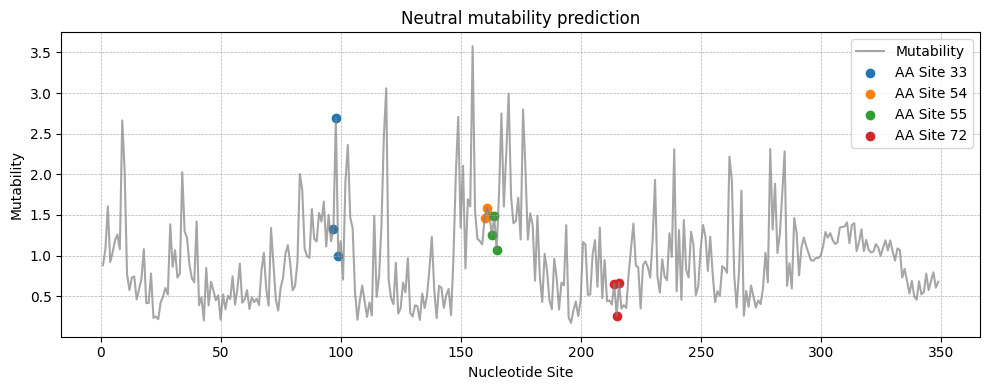

In [4]:
# filter for families of type 23D12 

peanut_df = pcp_df[
    (pcp_df["v_gene_heavy"] == "IGHV3-9*01") & 
    (pcp_df['j_gene_heavy'] == 'IGHJ4*02')
    #(pcp_df['family'].isin(large_families))
].copy()

# Create mutability container and plot
mut_peanut = MutabilityContainer(peanut_df, neutral_model_name)
fig = mut_peanut.plot_mutability_with_highlights([33, 54, 55, 72])


# Display the filtered dataframe
print(f"Filtered dataframe shape: {peanut_df.shape}")
peanut_df

In [5]:
## site 72 - (i.e. IMGT site 80) of IGHV3-9*01, IGHJ4*02 (R80) - the germline is R, but the paper says substitution for the germline should be to R. so ignore this for now.


top 5 codons (check to make sure we have a clear majority):
AGT    131
GGT     31
AGC     12
ACT      2
GGC      2
Name: count, dtype: int64


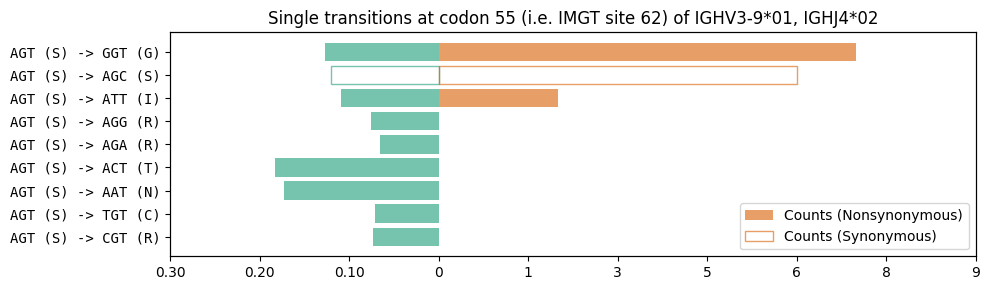

In [6]:
# Single transitions at codon 55 (i.e. IMGT site 62) of IGHV3-9*01, IGHJ4*02 (N62) - not exactly


fig, axs = plt.subplots(1, 1, figsize=(10, 3), sharex=True)

# For the first plot, we need to prepare the data properly
df_peanut = mut_peanut.single_codon_transition_df(55)
df_peanut = df_peanut[df_peanut["Counts"] >= 0]
df_peanut["Frequency"] = df_peanut["Counts"] / df_peanut["Counts"].sum()
df_peanut["Parent"] = df_peanut["Transition"].str.extract(r'(\w+) \(')
df_peanut = df_peanut.sort_values(['Parent', 'Frequency'], ascending=[False, True], kind='mergesort')


mut_peanut.plot_codon_transitions_aux(df_peanut, axs, show_probabilities=True, show_labels=False)
axs.set_title("Single transitions at codon 55 (i.e. IMGT site 62) of IGHV3-9*01, IGHJ4*02")

plt.tight_layout()

top 5 codons (check to make sure we have a clear majority):
AGA    179
CGA      1
Name: count, dtype: int64
           Transition  Counts Parent AA Child AA  Synonymous  Probability
0  AGA (R) -> CGA (R)     1.0         R        R        True     0.064457
1  AGA (R) -> GGA (G)     0.0         R        G       False     0.188784
2  AGA (R) -> TGA (*)     0.0       NaN      NaN       False     0.065227
3  AGA (R) -> AAA (K)     0.0         R        K       False     0.159833
4  AGA (R) -> ACA (T)     0.0         R        T       False     0.142635
5  AGA (R) -> ATA (I)     0.0         R        I       False     0.054890
6  AGA (R) -> AGC (S)     0.0         R        S       False     0.068648
7  AGA (R) -> AGG (R)     3.0         R        R        True     0.199200
8  AGA (R) -> AGT (S)     0.0         R        S       False     0.056327


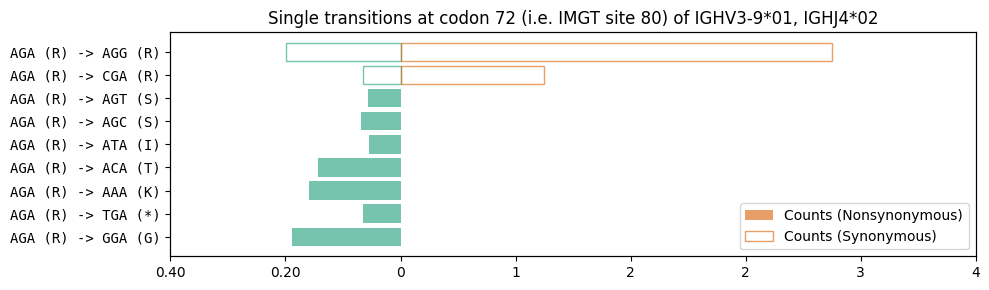

In [7]:
## site 72 - (i.e. IMGT site 80) of IGHV3-9*01, IGHJ4*02 (R80) - the germline is R, but the paper says substitution for the germline should be to R. so ignore this for now.

fig, axs = plt.subplots(1, 1, figsize=(10, 3), sharex=True)

# For the first plot, we need to prepare the data properly
df_peanut = mut_peanut.single_codon_transition_df(72)
print(df_peanut)
df_peanut = df_peanut[df_peanut["Counts"] >= 0]
df_peanut["Frequency"] = df_peanut["Counts"] / df_peanut["Counts"].sum()
df_peanut["Parent"] = df_peanut["Transition"].str.extract(r'(\w+) \(')
df_peanut = df_peanut.sort_values(['Parent', 'Frequency'], ascending=[False, True], kind='mergesort')

mut_peanut.plot_codon_transitions_aux(df_peanut, axs, show_probabilities=True, show_labels=False)
axs.set_title("Single transitions at codon 72 (i.e. IMGT site 80) of IGHV3-9*01, IGHJ4*02")

plt.tight_layout()

top 5 codons (check to make sure we have a clear majority):
AAT    149
GAT     11
AAC      8
AGT      7
GGC      4
Name: count, dtype: int64


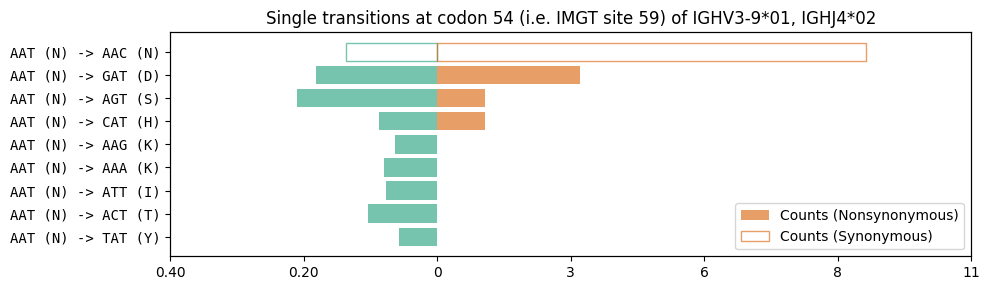

In [8]:
### Single transitions at codon 54 (i.e. IMGT site 59) to (K59) - there's two K possibilty codons, so need to sum them


fig, axs = plt.subplots(1, 1, figsize=(10, 3), sharex=True)

# For the first plot, we need to prepare the data properly
df_peanut = mut_peanut.single_codon_transition_df(54)
df_peanut = df_peanut[df_peanut["Counts"] >= 0]
df_peanut["Frequency"] = df_peanut["Counts"] / df_peanut["Counts"].sum()
df_peanut["Parent"] = df_peanut["Transition"].str.extract(r'(\w+) \(')
df_peanut = df_peanut.sort_values(['Parent', 'Frequency'], ascending=[False, True], kind='mergesort')

mut_peanut.plot_codon_transitions_aux(df_peanut, axs, show_probabilities=True, show_labels=False)
axs.set_title("Single transitions at codon 54 (i.e. IMGT site 59) of IGHV3-9*01, IGHJ4*02")

plt.tight_layout()


top 5 codons (check to make sure we have a clear majority):
GCC    145
ACC     13
GAC      8
GGC      7
TCC      4
Name: count, dtype: int64


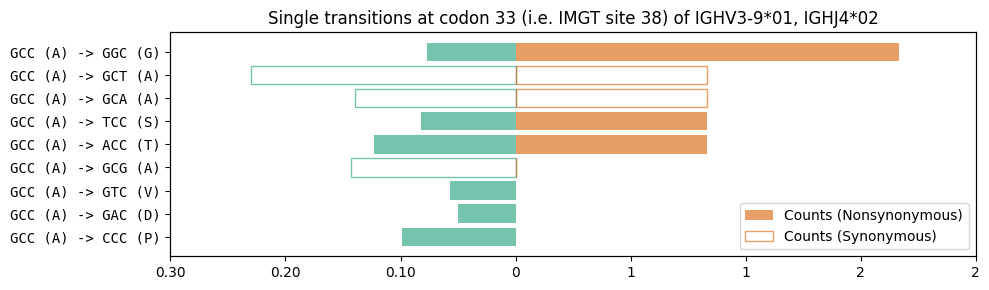

In [9]:
# Single transitions at codon 33 (i.e. IMGT site 38) of IGHV3-9*01, IGHJ4*02 (T38) - it is the second highest most probable, very close too


fig, axs = plt.subplots(1, 1, figsize=(10, 3), sharex=True)

# For the first plot, we need to prepare the data properly
df_peanut = mut_peanut.single_codon_transition_df(33)
df_peanut = df_peanut[df_peanut["Counts"] >= 0]
df_peanut["Frequency"] = df_peanut["Counts"] / df_peanut["Counts"].sum()
df_peanut["Parent"] = df_peanut["Transition"].str.extract(r'(\w+) \(')
df_peanut = df_peanut.sort_values(['Parent', 'Frequency'], ascending=[False, True], kind='mergesort')

mut_peanut.plot_codon_transitions_aux(df_peanut, axs, show_probabilities=True, show_labels=False)
axs.set_title("Single transitions at codon 33 (i.e. IMGT site 38) of IGHV3-9*01, IGHJ4*02")

plt.tight_layout()

#fig.savefig(figures_dir + f"codon_transitions_23_V34.svg")



## test the germline rates for 23D12

In [10]:
germline_IGHV3_9_01 = 'GAAGTGCAGCTGGTGGAGTCTGGGGGAGGCTTGGTACAGCCTGGCAGGTCCCTGAGACTCTCCTGTGCAGCCTCTGGATTCACCTTTGATGATTATGCCATGCACTGGGTCCGGCAAGCTCCAGGGAAGGGCCTGGAGTGGGTCTCAGGTATTAGTTGGAATAGTGGTAGCATAGGCTATGCGGACTCTGTGAAGGGCCGATTCACCATCTCCAGAGACAACGCCAAGAACTCCCTGTATCTGCAAATGAACAGTCTGAGAGCTGAGGACACGGCCTTGTATTACTGTGCAAAAGATA'
germline_IGHJ4_02 = 'ACTACTTTGACTACTGGGGCCAGGGAACCCTGGTCACCGTCTCCTCAG'

In [11]:
germline_seq = germline_IGHV3_9_01 + 'N'*4*3 + germline_IGHJ4_02 ## the paper only gives amino acid sequence, so no idea what the D section nucleotides are, so we just put Ns there. Different lengths of N did not change the rates.

crepe = pretrained.load(neutral_model_name)
rates, csp_logits = crepe([germline_seq])

len(germline_seq)

Loading model ThriftyHumV0.2-59
Using cached models: /home/nharel/re/netam/netam/_pretrained/thrifty-0.2.0.zip


358

In [12]:
def single_mut_df_of_csp_logits(csp_logits, aa_site, original_codon):
    per_codon_csps = F.softmax(csp_logits, dim=2).mean(axis=0)[(aa_site-1)*3:aa_site*3]
    per_codon_csps_df = pd.DataFrame(per_codon_csps.detach().numpy(), columns=["A", "C", "G", "T"])

    # Calculate single-mut transition probabilities.
    single_mut_transitions = []
    for i, nt in enumerate(original_codon):
        for mut_nt in "ACGT":
            if mut_nt != nt:
                # Create the mutated codon.
                mutated_codon = original_codon[:i] + mut_nt + original_codon[i+1:]
                # Get the mutation probability.
                prob = per_codon_csps_df.loc[i, mut_nt]
                single_mut_transitions.append((original_codon, mutated_codon, prob, i))

    # Convert single-mut transitions into a DataFrame.
    single_mut_df = pd.DataFrame(single_mut_transitions, columns=['From', 'To', 'Probability', "Mutated_Position"])
    return single_mut_df


In [13]:
'''
Single transitions at codon 54 (i.e. IMGT site 59) of IGHV3-9*01, IGHJ4*02 (K59) 
Single transitions at codon 55 (i.e. IMGT site 62) of IGHV3-9*01, IGHJ4*02 (N62) 
Single transitions at codon 72 (i.e. IMGT site 80) of IGHV3-9*01, IGHJ4*02 (R80) 
Single transitions at codon 33 (i.e. IMGT site 38) of IGHV3-9*01, IGHJ4*02 (T38) 
'''

for site in [54, 55, 72, 33]:
    temp_df = single_mut_df_of_csp_logits(csp_logits, site, germline_seq[3*(site-1):3*site])
    temp_df['transition_aas'] = str(site) + temp_df['From'].apply(codon_to_aa) + '>' + temp_df['To'].apply(codon_to_aa)
    print(temp_df.sort_values('Probability', ascending=False))

  From   To  Probability  Mutated_Position transition_aas
1  AAT  GAT     0.604415                 0          54N>D
4  AAT  AGT     0.572422                 1          54N>S
7  AAT  AAC     0.488482                 2          54N>N
6  AAT  AAA     0.295140                 2          54N>K
3  AAT  ACT     0.245448                 1          54N>T
0  AAT  CAT     0.240497                 0          54N>H
8  AAT  AAG     0.216378                 2          54N>K
5  AAT  ATT     0.182131                 1          54N>I
2  AAT  TAT     0.155088                 0          54N>Y
  From   To  Probability  Mutated_Position transition_aas
1  AGT  GGT     0.528562                 0          55S>G
7  AGT  AGC     0.486991                 2          55S>S
4  AGT  ACT     0.419226                 1          55S>T
3  AGT  AAT     0.339941                 1          55S>N
8  AGT  AGG     0.282050                 2          55S>R
5  AGT  ATT     0.240833                 1          55S>I
2  AGT  TGT   

[159, 160, 161, 162, 163, 164, 96, 97, 98]


<Axes: title={'center': 'Mutability of IGHV3-9*01 IGHJ4*02 Germline Sequence'}, xlabel='nt_site', ylabel='mutability'>

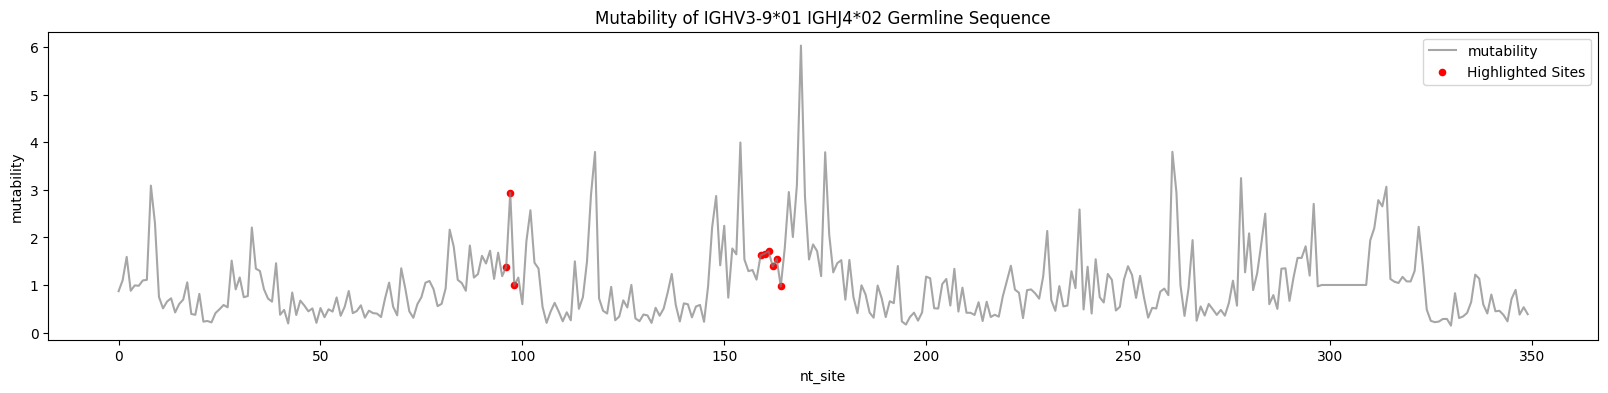

In [14]:
rates_df = pd.DataFrame(list(enumerate(rates[0])), columns=['nt_site', 'mutability'])
rates_df['mutability'] = rates_df.mutability.astype(float)
rates_df = rates_df[rates_df['nt_site'] < 350]  # Filter out sites beyond 350

nt_site_list = []
#for i in [54, 55, 72, 33]:
for i in [54, 55, 33]:
    nt_site_list.extend([3*(i-1), 3*(i-1)+1, 3*(i-1)+2])

print(nt_site_list)

ax = rates_df.plot(x='nt_site', y='mutability', kind='line', figsize=(20, 4), title='Mutability of IGHV3-9*01 IGHJ4*02 Germline Sequence', color='gray', alpha=0.7)
rates_df[rates_df.nt_site.isin(nt_site_list)].plot(
    x='nt_site', y='mutability', kind='scatter', ax=ax, color='red', label='Highlighted Sites'
)

In [15]:
# Convert logits to probabilities using PyTorch operations
csp_probs = torch.softmax(csp_logits, dim=-1)

# Convert to numpy for easier manipulation if needed
csp_probs_np = csp_probs.detach().cpu().numpy()

# Print dimensions for debugging
print(f"Length of germline_seq: {len(germline_seq)}")
print(f"Shape of rates: {rates.shape}")
print(f"Shape of csp_probs_np: {csp_probs_np.shape}")

# Define nucleotide mapping
nucleotides = ['A', 'C', 'G', 'T']

# Create empty list to store rows
data = []

# Use the minimum length to avoid index errors
seq_length = min(len(germline_seq), len(rates[0]), len(csp_probs_np[0]))
print(f"Using sequence length: {seq_length}")

# Loop through each site
for site_idx in range(seq_length):
    site_rate = rates[0][site_idx]
    site_probs = csp_probs_np[0][site_idx]
    ref_nucleotide = germline_seq[site_idx]
    
    # Skip 'N' positions or handle them specially
    if ref_nucleotide == 'N':
        continue  # Skip N positions
    
    ref_idx = nucleotides.index(ref_nucleotide)
    
    # Loop through possible mutations at this site
    for mut_idx, mut_nucleotide in enumerate(nucleotides):
        if mut_nucleotide != ref_nucleotide:  # Skip if it's not a mutation
            # Calculate final rate = site_rate * probability of mutation
            final_rate = site_rate * site_probs[mut_idx]
            
            # Add row to data
            data.append({
                'site': site_idx + 1,  # 1-indexed for readability
                'position': site_idx,   # 0-indexed (original position)
                'reference': ref_nucleotide,
                'mutation': mut_nucleotide,
                'site_rate': site_rate,
                'mutation_probability': site_probs[mut_idx],
                'final_rate': final_rate
            })

# Create DataFrame
df_mutations = pd.DataFrame(data)

# Display the top mutations
df_mutations.head(10)

Length of germline_seq: 358
Shape of rates: torch.Size([1, 500])
Shape of csp_probs_np: (1, 500, 4)
Using sequence length: 358


,site,position,reference,mutation,site_rate,mutation_probability,final_rate
0,1,0,G,A,tensor(0.8702),0.237886,tensor(0.2070)
1,1,0,G,C,tensor(0.8702),0.433961,tensor(0.3776)
2,1,0,G,T,tensor(0.8702),0.328153,tensor(0.2856)
3,2,1,A,C,tensor(1.0989),0.287412,tensor(0.3158)
4,2,1,A,G,tensor(1.0989),0.451477,tensor(0.4961)
5,2,1,A,T,tensor(1.0989),0.261111,tensor(0.2869)
6,3,2,A,C,tensor(1.5903),0.305115,tensor(0.4852)
7,3,2,A,G,tensor(1.5903),0.450571,tensor(0.7165)
8,3,2,A,T,tensor(1.5903),0.244314,tensor(0.3885)
9,4,3,G,A,tensor(0.8792),0.463528,tensor(0.4075)


"\nSingle transitions at codon 54 (i.e. IMGT site 59) resulting in codon K59 - there's two K possibilty codons, for a total of 0.5\nSingle transitions at codon 55 (i.e. IMGT site 62) of IGHV3-9*01, IGHJ4*02 (N62) - not exactly\nSingle transitions at codon 72 (i.e. IMGT site 80) of IGHV3-9*01, IGHJ4*02 (R80) - the germline is R, but the paper says the germline should be different than R..\nSingle transitions at codon 33 (i.e. IMGT site 38) of IGHV3-9*01, IGHJ4*02 (T38) - it is the second highest most probable, very close too\n"

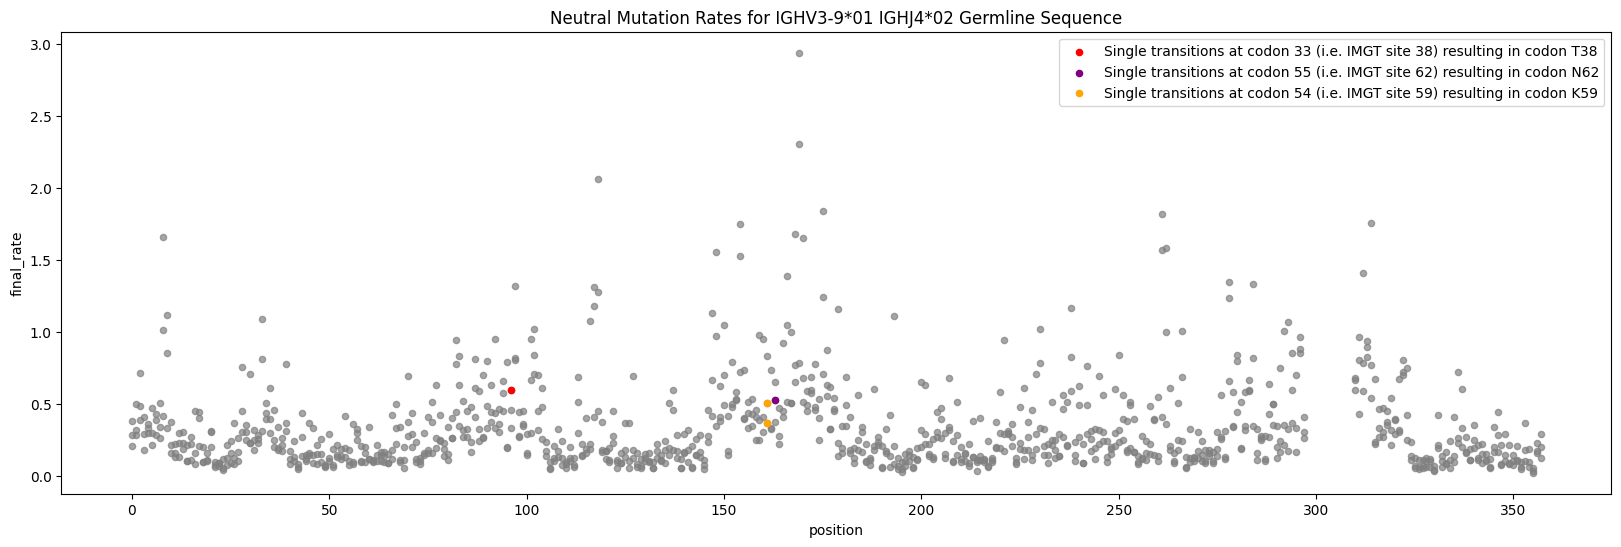

In [16]:
df_mutations['final_rate'] = df_mutations['final_rate'].astype(float)
ax = df_mutations.plot(x='position', y='final_rate', kind='scatter', figsize=(15, 6), title='Neutral Mutation Rates for IGHV3-9*01 IGHJ4*02 Germline Sequence', color='gray', alpha=0.7)
df_mutations[((df_mutations.position == 96) & (df_mutations.mutation == 'A'))].plot(
    x='position', y='final_rate', kind='scatter', figsize=(20, 6), label='Single transitions at codon 33 (i.e. IMGT site 38) resulting in codon T38', color='red', ax=ax)
df_mutations[((df_mutations.position == 163) & (df_mutations.mutation == 'A'))].plot(
    x='position', y='final_rate', kind='scatter', figsize=(20, 6), label='Single transitions at codon 55 (i.e. IMGT site 62) resulting in codon N62', color='purple', ax=ax)
df_mutations[((df_mutations.position == 161) & (df_mutations.mutation == 'A')) | 
             ((df_mutations.position == 161) & (df_mutations.mutation == 'G'))].plot(
    x='position', y='final_rate', kind='scatter', figsize=(20, 6), label='Single transitions at codon 54 (i.e. IMGT site 59) resulting in codon K59', color='orange', ax=ax)


'''
Single transitions at codon 54 (i.e. IMGT site 59) resulting in codon K59 - there's two K possibilty codons, for a total of 0.5
Single transitions at codon 55 (i.e. IMGT site 62) of IGHV3-9*01, IGHJ4*02 (N62) - not exactly
Single transitions at codon 72 (i.e. IMGT site 80) of IGHV3-9*01, IGHJ4*02 (R80) - the germline is R, but the paper says the germline should be different than R..
Single transitions at codon 33 (i.e. IMGT site 38) of IGHV3-9*01, IGHJ4*02 (T38) - it is the second highest most probable, very close too
'''

In [17]:
# Calculate percentiles for specific transitions
specific_transitions = [
    (96, 'A'),   # Codon 33, IMGT site 38
    (163, 'A'),  # Codon 55, IMGT site 62
    (161, 'A'),  # Codon 54, IMGT site 59
    (161, 'G')   # Codon 54, IMGT site 59
]

for position, mutation in specific_transitions:
    subset = df_mutations[
        (df_mutations['position'] == position) & 
        (df_mutations['mutation'] == mutation)
    ]
    
    # Calculate percentile
    percentile = df_mutations['final_rate'].rank(pct=True) * 100
    
    specific_percentile = percentile[
        (df_mutations['position'] == position) & 
        (df_mutations['mutation'] == mutation)
    ].values[0]
    
    print(f"Position {position}, Mutation {mutation}:")
    print(f"Rate: {subset['final_rate'].values[0]}")
    print(f"Percentile: {specific_percentile:.2f}%")
    print()

Position 96, Mutation A:
Rate: 0.5953511595726013
Percentile: 86.22%

Position 163, Mutation A:
Rate: 0.5259990692138672
Percentile: 83.53%

Position 161, Mutation A:
Rate: 0.5034545063972473
Percentile: 81.70%

Position 161, Mutation G:
Rate: 0.3691003918647766
Percentile: 70.23%



<Axes: >

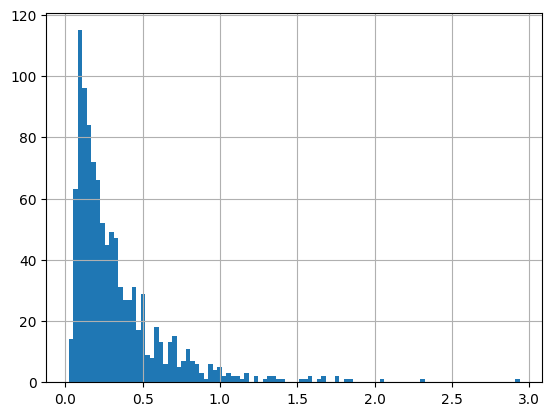

In [18]:
df_mutations['final_rate'].hist(bins=100)